# Salary Prediction with Regression Models

## 1. Introduction

For the project work, I decided to analyze how factors such as age, education level, work experience, and job type affect salary. The research question is: **how accurately can salary be predicted using these variables, and which are the explanatory factors of salary?**

To address this question, I used linear regression and regularized regression methods (Ridge and Lasso). These models' performance is evaluated using training and test data, and results are analyzed to understand the predictive accuracy and the importance of different variables.

## 2. Data

The dataset used is the [Salary_Data dataset from Kaggle](https://www.kaggle.com/datasets/mohithsairamreddy/salary-data). It includes 6 variables: age, education level, job title, years of experience, and salary. Originally, the dataset included 6704 observations.

I started by exploring the data, and found there to be several missing values, which I handled by replacing missing values in numerical variables with the median value, and missing values in categorical variables with the most frequent category. The minimum salary seems to be 350, which is a very small number and could be considered an outlier.

I also noted that the majority of the dataset was actually duplicate observations (4912 out of 6704, to be exact). The reason for this is most likely that the data is artificially generated. I decided to remove the duplicate rows to have a more accurate representation of the variables, reducing possible bias caused by repeated observations. This reduced the number of observations from 6704 to 1792.

By printing the different unique values of each categorical variable (gender, job title, and education level), I found that there were inconsistencies in the spelling of education level, and there were also 194 different job titles. To mitigate issues caused by the variance in variables, I standardized the spelling of the education levels and grouped job titles by category, reducing data dimensionality. I decided to leave the job titles as they were, however, risking the amount of variance to grow, but possibly making regularization more useful.

## 3. Methodology

The goal is to model the relationship between the input variables and the target variable (salary). I decided to go forward with regression-based methods.

I started by dividing the dataset into a training set and a test set, using the training set to estimate the model parameters, and the test set to evaluate the model's performance on unseen data. The data was split, with 75% of the data used for training and 25% for testing.

I started by modeling the data with **linear regression**, which models the relationship between the predictors and the target variable as a linear function. It is good to note, however, that linear regression is prone to overfitting when there are a large number of features or noise in the data.

To address this, I also applied the regularized regression methods, **Ridge regression** and **Lasso regression**, to the data. Both add a penalty term to the model that shrinks the coefficients, reducing variance. The difference between the two is that Ridge regression shrinks the coefficients close to zero, while Lasso regression can shrink some to exactly zero, performing feature selection. The hyperparameters for these models were selected using cross-validation to ensure that the hyperparameters generalize well and don't depend on a single split of the data.

I then evaluated model performance with **mean squared error (MSE)** and the **coefficient of determination (R²)**, as well as training and test errors, to detect any overfitting and to assess the model's ability to generalize.

## 4. Code
### 4.1 Imports

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

### 4.2 Data Preparation

In [6]:
# Load data and check basic info
data = pd.read_csv("/Users/millajylanki/Downloads/Salary_Data.csv")
data.info()
print(data.head())
print(data.describe())
print("gender:", data["Gender"].unique())
print("education level:", data["Education Level"].unique())
print("job title:", data["Job Title"].unique())

<class 'pandas.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6702 non-null   float64
 1   Gender               6702 non-null   str    
 2   Education Level      6701 non-null   str    
 3   Job Title            6702 non-null   str    
 4   Years of Experience  6701 non-null   float64
 5   Salary               6699 non-null   float64
dtypes: float64(3), str(3)
memory usage: 314.4 KB
    Age  Gender Education Level          Job Title  Years of Experience  \
0  32.0    Male      Bachelor's  Software Engineer                  5.0   
1  28.0  Female        Master's       Data Analyst                  3.0   
2  45.0    Male             PhD     Senior Manager                 15.0   
3  36.0  Female      Bachelor's    Sales Associate                  7.0   
4  52.0    Male        Master's           Director                 20.0   

    

In [7]:
# Handle missing values
print(data.isna().sum())

# Fill numeric columns with median
numeric_cols = data.select_dtypes(include="number").columns
data[numeric_cols] = data[numeric_cols].fillna(data[numeric_cols].median())

# Fill categorical columns with most common value
categorical_cols = data.select_dtypes(exclude="number").columns
for col in categorical_cols:
    data[col] = data[col].fillna(data[col].mode()[0])

Age                    2
Gender                 2
Education Level        3
Job Title              2
Years of Experience    3
Salary                 5
dtype: int64


In [8]:
# Remove duplicates
print("Duplicates:", data.duplicated().sum())
print("Before:", data.shape)
data = data.drop_duplicates()
print("After:", data.shape)

Duplicates: 4912
Before: (6704, 6)
After: (1792, 6)


In [9]:
# Standardize education level spellings
data["Education Level"] = data["Education Level"].str.strip().str.lower()

education_mapping = {
    "bachelor's": "bachelor",
    "bachelor's degree": "bachelor",
    "master's": "master",
    "master's degree": "master",
}
data["Education Level"] = data["Education Level"].replace(education_mapping)
print("New education levels:", data["Education Level"].unique())

New education levels: <StringArray>
['bachelor', 'master', 'phd', 'high school']
Length: 4, dtype: str


### 4.3 Linear Regression

In [10]:
# Define features and target
X = data.drop(columns=["Salary"])
y = data["Salary"]

# Separate numeric and categorical features
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()
print("Numeric:", numeric_features)
print("Categorical:", categorical_features)

# Build preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

Numeric: ['Age', 'Years of Experience']
Categorical: ['Gender', 'Education Level', 'Job Title']


Linear Regression — Train R²: 0.8634, Test R²: 0.8424
Linear Regression — Train MSE: 367309194.13, Test MSE: 401460223.49


/Users/millajylanki/.venv/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


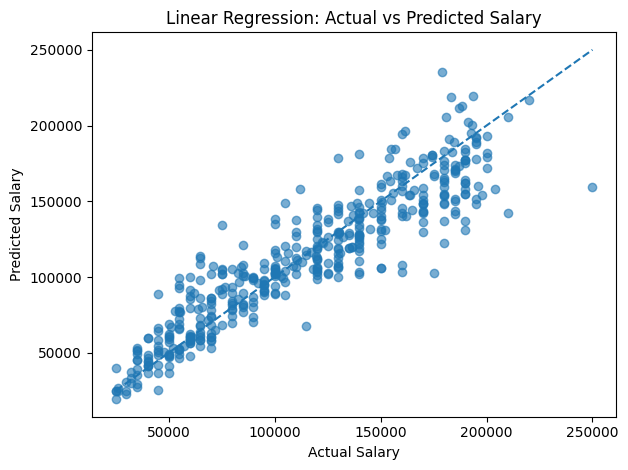

In [11]:
# Fit linear regression model
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
y_train_pred = model.predict(X_train)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)

print(f"Linear Regression — Train R²: {r2_train:.4f}, Test R²: {r2:.4f}")
print(f"Linear Regression — Train MSE: {mse_train:.2f}, Test MSE: {mse:.2f}")

# Plot
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "--")
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Linear Regression: Actual vs Predicted Salary")
plt.tight_layout()
plt.show()

### 4.4 Regularized Regression (Ridge & Lasso)

In [12]:
# Ridge model (automatic alpha tuning via cross-validation)
ridge_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RidgeCV(alphas=np.logspace(-3, 3, 50)))
])

# Lasso model (automatic alpha tuning via cross-validation)
lasso_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LassoCV(alphas=np.logspace(-3, 1, 50), max_iter=20000, random_state=42))
])

# Train Ridge
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)
y_train_pred_ridge = ridge_model.predict(X_train)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
mse_train_ridge = mean_squared_error(y_train, y_train_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)
r2_train_ridge = r2_score(y_train, y_train_pred_ridge)

# Train Lasso
lasso_model.fit(X_train, y_train)
y_pred_lasso = lasso_model.predict(X_test)
y_train_pred_lasso = lasso_model.predict(X_train)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
mse_train_lasso = mean_squared_error(y_train, y_train_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)
r2_train_lasso = r2_score(y_train, y_train_pred_lasso)

/Users/millajylanki/.venv/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/millajylanki/.venv/lib/python3.14/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


Training vs Test comparison:
    Model     Train MSE      Test MSE  Train R²   Test R²
0  Linear  3.673092e+08  4.014602e+08  0.863394  0.842368
1   Ridge  3.737051e+08  3.979158e+08  0.861015  0.843760
2   Lasso  3.738926e+08  3.973705e+08  0.860945  0.843974


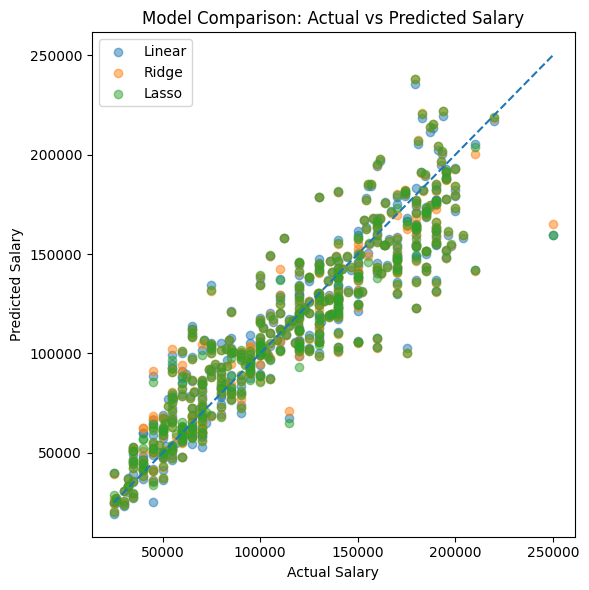

In [13]:
# Compare all models
comparison = pd.DataFrame({
    "Model": ["Linear", "Ridge", "Lasso"],
    "Train MSE": [mse_train, mse_train_ridge, mse_train_lasso],
    "Test MSE": [mse, mse_ridge, mse_lasso],
    "Train R²": [r2_train, r2_train_ridge, r2_train_lasso],
    "Test R²": [r2, r2_ridge, r2_lasso]
})
print("Training vs Test comparison:")
print(comparison)

# Visual comparison
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.5, label="Linear")
plt.scatter(y_test, y_pred_ridge, alpha=0.5, label="Ridge")
plt.scatter(y_test, y_pred_lasso, alpha=0.5, label="Lasso")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "--")
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.legend()
plt.title("Model Comparison: Actual vs Predicted Salary")
plt.tight_layout()
plt.show()

### 4.5 Analysis: Feature Importance

In [14]:
# Best alpha values selected by cross-validation
ridge_alpha = ridge_model.named_steps["regressor"].alpha_
lasso_alpha = lasso_model.named_steps["regressor"].alpha_
print("Best Ridge alpha:", ridge_alpha)
print("Best Lasso alpha:", lasso_alpha)

# Get feature names after one-hot encoding
onehot = preprocessor.named_transformers_["cat"].named_steps["onehot"]
cat_names = onehot.get_feature_names_out(categorical_features)
feature_names = numeric_features + list(cat_names)

# Lasso coefficients (with feature selection)
lasso_coefs = lasso_model.named_steps["regressor"].coef_
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": lasso_coefs
}).sort_values(by="Coefficient", key=abs, ascending=False)
print(coef_df)

Best Ridge alpha: 0.49417133613238334
Best Lasso alpha: 6.866488450042998
                                Feature   Coefficient
11         Job Title_Chief Data Officer  78733.312324
12   Job Title_Chief Technology Officer  72348.993602
30   Job Title_Director of Data Science  66513.421090
105         Job Title_Research Director  61882.133375
22             Job Title_Data Scientist  61481.670774
..                                  ...           ...
86     Job Title_Juniour HR Coordinator     -0.000000
64   Job Title_Junior Financial Advisor     -0.000000
63           Job Title_Junior Developer     -0.000000
153         Job Title_Senior Researcher      0.000000
89      Job Title_Marketing Coordinator      0.000000

[178 rows x 2 columns]


## 5. Results

All models produced very similar results. Ridge and Lasso slightly improved the test performance compared to the linear model, with very small differences, suggesting that overfitting is not a major issue and the benefits of regularization are not exceedingly visible.

Comparing training and test performance shows that all models generalize well. Training errors for all models were 0.86, and test errors were 0.84. Since there is a very small gap between training and test errors, the models are not overfitting in a significant way, and perform consistently on test data.

I analysed the model coefficients to find which factors influence salary the most:
- The strongest predictor was **years of experience**, which had a large positive effect on salary.
- Higher levels of education, such as a **PhD or Master's degree**, are associated with higher salaries, while lower education levels correspond to lower salaries.
- **Job category** also affected salary, with tech and management roles associated with higher salaries and sales, marketing, and human resources corresponding to lower ones.
- **Gender and age** had much smaller effects compared to other coefficients.

Lasso regularization performed feature selection and removed some coefficients, since they were reduced to zero. The results show that salary can be predicted with reasonable accuracy using these selected features.

## 6. Critical Evaluation

Several limitations of the analysis need to be recognized:

1. **Data quality**: The dataset included a large number of duplicate observations, meaning that the data may not represent real-world variability. Since duplicates were removed, this reduced the dataset size significantly and may affect the usability of the results.

2. **Outliers**: The extremely low salary value outliers were not addressed, which can have a negative effect on model performance, since linear models can be sensitive to extreme values.

3. **Job title granularity**: The number of different job titles increases model complexity a lot. While they could have been grouped to have smaller amounts of coefficients, this could also lead to a loss of detailed information and less predictive accuracy. This problem is a good example of trading model simplicity for predictive performance.

Despite this, the analysis provides useful insights into which factors affect salary, showing that years of experience, education level, and job category determine salary the most, while age and gender have a much smaller effect.

This study indicates that simple regression models are usable for salary prediction with reasonable accuracy, while data quality and feature selection are important for making sure results are reliable and easy to understand.